In [17]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# Path setup
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

from src.data import load_raw_data

# Set style
sns.set(style="whitegrid", context="notebook", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)

# Load Data
df = load_raw_data()

# conduct some initial EDA
df.head()
df.info()
df.describe()

# Wilson Score Interval for Binomial Confidence ---
def wilson_interval(k, n, confidence=0.95):
    """
    Calculate the lower and upper bound of the Wilson Score Interval.
    k: number of successes (frauds)
    n: total trials (transactions)
    """
    if n == 0: return 0, 0
    z = norm.ppf(1 - (1 - confidence) / 2)
    p = k / n
    denominator = 1 + z**2/n
    center = (p + z**2 / (2*n)) / denominator
    spread = z * np.sqrt(p*(1-p)/n + z**2/(4*n**2)) / denominator
    return center - spread, center + spread



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19


### 1) Distribution of Log-Transformed Amount (P(Amount | Class)) — KDE plot

This aims to show how transaction amounts are distributed within each class (normal vs fraud), using a smoothed density curve. This answers:

“Given it’s fraud (or not), what amounts are typical?”
That’s p(Amount∣Class), not fraud risk.


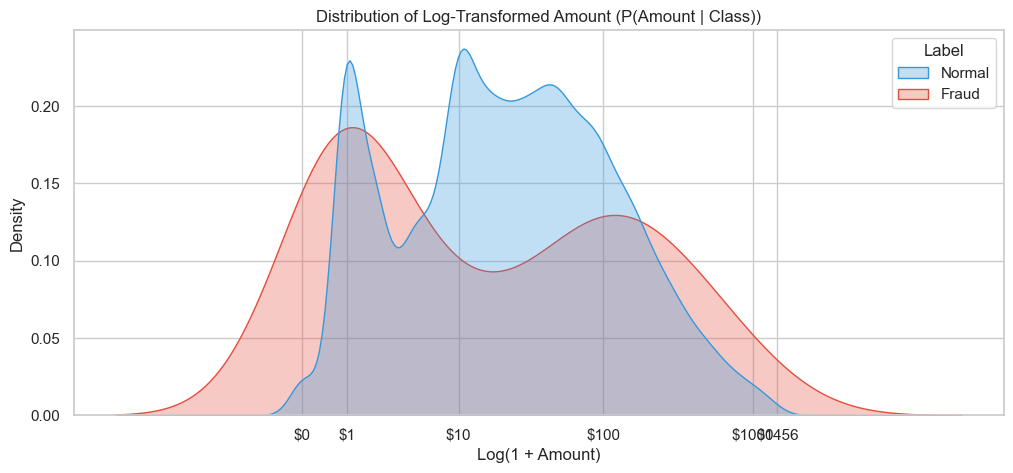

In [18]:
# 1. Prepare Data: Log transform
df['log_Amount'] = np.log1p(df['Amount'])

# 2. Clip extremes for better visualization (99.5th percentile)
cap_val = df['log_Amount'].quantile(0.995)
df_viz = df[df['log_Amount'] <= cap_val].copy()

# 3. Rename classes for legend readability
df_viz['Label'] = df_viz['Class'].map({0: 'Normal', 1: 'Fraud'})

plt.figure(figsize=(12, 5))
sns.kdeplot(
    data=df_viz, x='log_Amount', hue='Label',
    fill=True, common_norm=False,
    palette={"Normal": "#3498db", "Fraud": "#e74c3c"},
    alpha=0.3,
    bw_adjust=1.5  # SMOOTHING FIX: Makes curves less jagged
)
plt.title("Distribution of Log-Transformed Amount (P(Amount | Class))")
plt.xlabel("Log(1 + Amount)")
plt.ylabel("Density")

# Annotate real dollar values
ticks = [0, 1, 10, 100, 1000, int(np.expm1(cap_val))]
log_ticks = [np.log1p(t) for t in ticks]
plt.xticks(log_ticks, [f"${t}" for t in ticks])
plt.show()

#### What the result suggests:

1) Fraud has a strong peak around very small transactions - around 1 dollar and another broad hump around $100-$1000 dollars

2) Normal (blue) has a lot of mass in the ~$10–$100 dollar region, with a more complex multi-peaked shape.

There’s large overlap: Amount alone won’t cleanly separate fraud vs non-fraud, but it does show different “amount regimes” where fraud is relatively more common within fraud transactions.

Important caveat: This plot does not show P(Fraud∣Amount). This could be misread as “fraud probability by amount” — I'll be showing this in the next plot.


### 2) Fraud Risk by Amount (Red Line) vs Sample Size (Grey Bars)

Grey bars = how many transactions fall into each amount bin (left y-axis, log scale).

Red line = fraud rate in each bin (right y-axis), i.e.
P(Fraud∣Amount in bin)

This graph attempts to answer: “How does fraud risk change with transaction amount, and how confident can I be in each estimate?”

It combines three ideas in one figure:

1. Bin the Amount values (log-spaced bins)
Because Amount spans orders of magnitude, log bins avoid the “everything piles into the first bin” problem and make comparisons fair across small and large transactions.

2. Estimate fraud rate per bin
For each bin, I compute:

* n = number of transactions in the bin
* k = number of frauds in the bin
* rate = 100×k/n

   The red dots and dashed line show the fraud rate (%) across bins.

3. Quantify uncertainty with 95% confidence intervals (Wilson)
Fraud is rare, and some bins have few samples. The vertical error bars show a 95% confidence interval for the fraud rate in that bin, so the chart doesn’t overclaim where data are scarce.

4. Show sample size at the same time
The grey bars (log scale, left axis) show n in each bin. This is vital because a “high fraud rate” in a tiny bin can be meaningless — and the chart makes that immediately obvious.

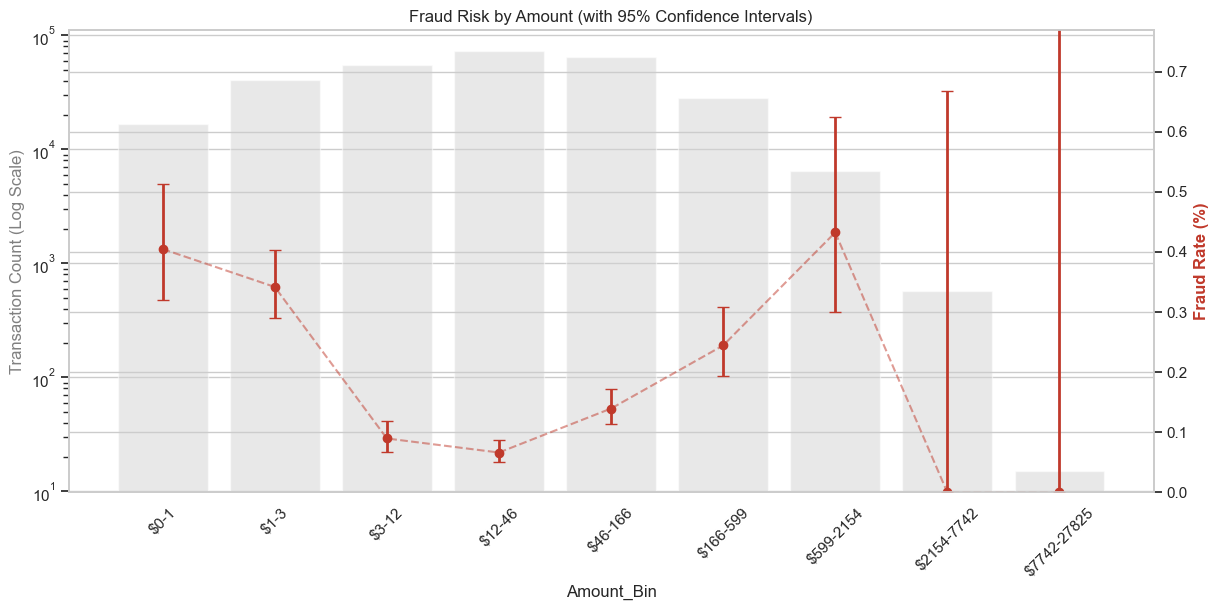

In [22]:
# 1) Bins
bins = np.concatenate(([0], np.logspace(0, 5, num=10)))
df['Amount_Bin'] = pd.cut(df['Amount'], bins=bins, right=False)

# 2) Bin stats
bin_stats = df.groupby('Amount_Bin', observed=False)['Class'].agg(n='count', k='sum').reset_index()

# Guard against empty bins (shouldn't happen often, but safe)
bin_stats = bin_stats[bin_stats['n'] > 0].copy()

# 3) Wilson CI (assumes wilson_interval returns proportions in [0,1])
ci = bin_stats.apply(lambda r: wilson_interval(r['k'], r['n']), axis=1)
bin_stats['lower'] = [c[0] for c in ci]
bin_stats['upper'] = [c[1] for c in ci]

# Convert to %
bin_stats['rate'] = (bin_stats['k'] / bin_stats['n']) * 100
bin_stats['lower_pct'] = bin_stats['lower'] * 100
bin_stats['upper_pct'] = bin_stats['upper'] * 100

# Asymmetric errors for matplotlib
yerr = np.vstack([
    bin_stats['rate'] - bin_stats['lower_pct'],
    bin_stats['upper_pct'] - bin_stats['rate']
])

# 4) Plot
fig, ax1 = plt.subplots(figsize=(14, 6))

# Grey bars: sample size
sns.barplot(data=bin_stats, x='Amount_Bin', y='n', ax=ax1, color='lightgrey', alpha=0.5)
ax1.set_ylabel("Transaction Count (Log Scale)", color="gray")
ax1.set_yscale('log')

# Red points + CI
ax2 = ax1.twinx()
x = np.arange(len(bin_stats))

ax2.errorbar(
    x=x,
    y=bin_stats['rate'],
    yerr=yerr,
    fmt='o',
    color='#c0392b',
    elinewidth=2,
    capsize=4,
    label='Fraud Rate (95% Wilson CI)'
)
ax2.plot(x, bin_stats['rate'], color='#c0392b', alpha=0.5, linestyle='--')

ax2.set_ylabel("Fraud Rate (%)", color="#c0392b", weight='bold')
ax2.set_ylim(bottom=0)

# set y-limit based on bins with decent sample size ---
MIN_N = 200  # tune: 100, 200, 500 depending on how strict you want to be
reliable = bin_stats['n'] >= MIN_N
if reliable.any():
    ymax = bin_stats.loc[reliable, 'upper_pct'].max()
    ax2.set_ylim(0, ymax * 1.15)  # small headroom

plt.title("Fraud Risk by Amount (with 95% Confidence Intervals)")

# Labels
labels = [f"${int(b.left)}-{int(b.right)}" for b in bin_stats['Amount_Bin']]
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=45)

plt.show()

#### What the result suggests:

A) Fraud risk is not monotonic with amount

From the red line:

* Very small amounts ($0–$1, $1–$3) show relatively elevated fraud rates.
* Fraud risk then drops sharply in the low-to-mid region (roughly $3–$46), where the dots sit near the bottom and the CIs are fairly tight (high n).
* Risk then rises again through the mid-high bins ($46–$599), suggesting increasing risk with amount over that range.
* There’s a notable peak around $599–$2154, where the fraud rate is again comparatively high.

Interpretation: this pattern is consistent with two common fraud behaviours:

* tiny “test charges” to validate a card
* larger “cash-out” charges once the card works

B) The most reliable conclusions are in the bins with large n

The middle bins have tall grey bars (lots of transactions), and their error bars are modest — meaning:

* those fraud-rate estimates are stable
* the “dip then rise” pattern in the mid-range is worth lookin at seriously

C) The far-right bins are too data-sparse to interpret

The last bins (e.g 2154-7742 dollars and 7742-27825 dollars) have:

* very small counts (tiny grey bars)
* massive confidence intervals

That means: I cannot confidently say fraud is low or high there — only that the dataset doesn’t contain enough examples in those ranges to estimate the risk precisely.


### 3) Fraud Probability by Hour (with 95% Confidence Intervals)

The goal here is to test whether fraud is more likely at certain times (an “hourly risk profile”), i.e. whether: P(Fraud∣Hour) varies across the 24-hour cycle.

How it does it:

1. For each hour bucket (0–23), I compute the fraud rate: mean of Class within that hour, then convert to %.

2. You add 95% confidence intervals per hour (error bars), which communicate uncertainty:

* narrow CI = stable estimate (lots of data / consistent rate),
* wide CI = noisy estimate (few samples / rare events).

3. The line connecting points helps me visually track the pattern across hours.

(And the x-label “Approx / Relative” is the right kind of caution for this dataset, where Time is “seconds since start”, not guaranteed true local time-of-day.)


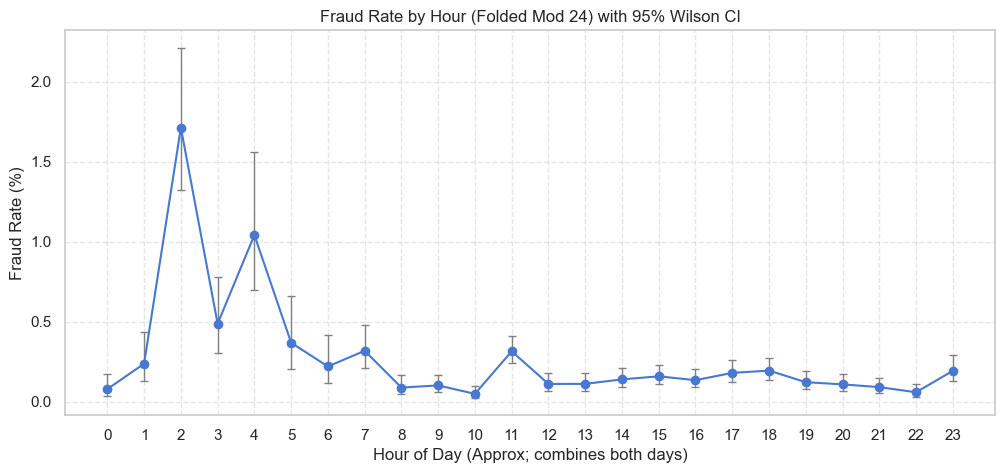

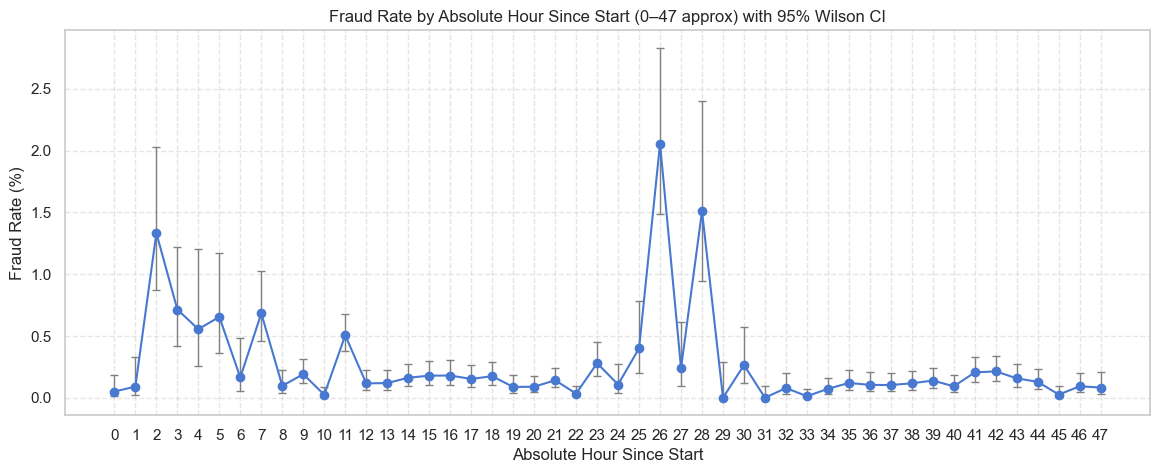

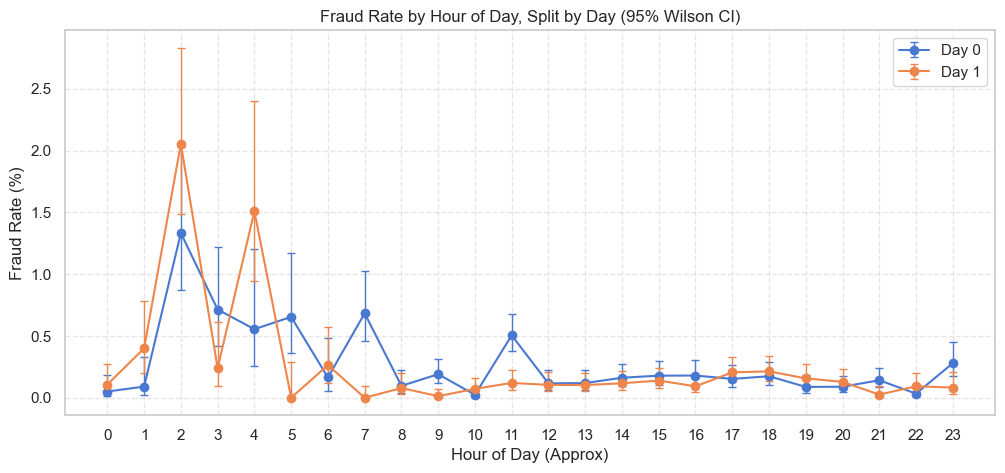

In [23]:
# --- helper for asymmetric Wilson error bars (Matplotlib expects 2xN for asymmetric) ---
def add_wilson_ci(stats_df, k_col='k', n_col='n'):
    stats_df = stats_df.copy()

    ci = stats_df.apply(lambda r: wilson_interval(r[k_col], r[n_col]), axis=1)
    stats_df['lower'] = [c[0] for c in ci]
    stats_df['upper'] = [c[1] for c in ci]

    stats_df['rate'] = (stats_df[k_col] / stats_df[n_col]) * 100
    lower_pct = stats_df['lower'] * 100
    upper_pct = stats_df['upper'] * 100

    yerr = np.vstack([
        stats_df['rate'] - lower_pct,   # down
        upper_pct - stats_df['rate']    # up
    ])
    return stats_df, yerr

# ---- build time features ----
df['Hour_Abs'] = (df['Time'] // 3600).astype(int)      # 0..~47
df['Day'] = (df['Time'] // 86400).astype(int)          # 0..1
df['Hour_Mod24'] = (df['Hour_Abs'] % 24).astype(int)   # 0..23

# ==========================
# Plot A: Mod 24 (folded)

hourly_mod = df.groupby('Hour_Mod24')['Class'].agg(n='count', k='sum').reset_index()
hourly_mod, yerr_mod = add_wilson_ci(hourly_mod)

plt.figure(figsize=(12, 5))
plt.errorbar(
    x=hourly_mod['Hour_Mod24'], y=hourly_mod['rate'], yerr=yerr_mod,
    fmt='-o', ecolor='gray', elinewidth=1, capsize=3
)
plt.title("Fraud Rate by Hour (Folded Mod 24) with 95% Wilson CI")
plt.ylabel("Fraud Rate (%)")
plt.xlabel("Hour of Day (Approx; combines both days)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(range(0, 24))
plt.show()

# ==========================
# Plot B: Absolute hour (0..~47)

hourly_abs = df.groupby('Hour_Abs')['Class'].agg(n='count', k='sum').reset_index()
hourly_abs, yerr_abs = add_wilson_ci(hourly_abs)

plt.figure(figsize=(14, 5))
plt.errorbar(
    x=hourly_abs['Hour_Abs'], y=hourly_abs['rate'], yerr=yerr_abs,
    fmt='-o', ecolor='gray', elinewidth=1, capsize=3
)
plt.title("Fraud Rate by Absolute Hour Since Start (0–47 approx) with 95% Wilson CI")
plt.ylabel("Fraud Rate (%)")
plt.xlabel("Absolute Hour Since Start")
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(range(int(hourly_abs['Hour_Abs'].min()), int(hourly_abs['Hour_Abs'].max()) + 1))
plt.show()

# ==========================
# Plot C: Split by Day 0 vs Day 1 (each 0..23)
#
hourly_by_day = df.groupby(['Day', 'Hour_Mod24'])['Class'].agg(n='count', k='sum').reset_index()

plt.figure(figsize=(12, 5))
for day in sorted(hourly_by_day['Day'].unique()):
    tmp = hourly_by_day[hourly_by_day['Day'] == day].copy()
    tmp, yerr = add_wilson_ci(tmp)
    plt.errorbar(
        x=tmp['Hour_Mod24'], y=tmp['rate'], yerr=yerr,
        fmt='-o', elinewidth=1, capsize=3, label=f'Day {day}'
    )

plt.title("Fraud Rate by Hour of Day, Split by Day (95% Wilson CI)")
plt.ylabel("Fraud Rate (%)")
plt.xlabel("Hour of Day (Approx)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(range(0, 24))
plt.legend()
plt.show()

#### What the result suggests:

There’s a sharp spike around hour ~2, and another noticeable elevation around hour ~4.

After about hour 5, fraud rate generally drops and flattens, with only smaller bumps (e.g., around hour ~11 and modest undulations later).

The confidence intervals are widest around the big early spikes, which usually means:

either fewer observations in those buckets, or

high variance driven by a small number of fraud cases.
Even so, the spike is large enough that it still looks like a real pattern worth noting.

Practical implication: time-derived features may add signal, but you should treat this as suggestive rather than definitive (because “hour of day” is constructed from relative time, and because CIs show uncertainty is non-trivial in places).

### 4) Top Feature Distributions vs Class (Boxen plots: V17, V14, V12, V10, V16, V3)

This graph aims to show whether the most “fraud-informative” features (here, the ones with the largest absolute correlation with Class) have visibly different distributions for Fraud vs Normal.

How it achieves this:

* Each panel takes one feature (e.g., V17) and compares its values for the two labels.
* A boxen plot (a richer version of a box plot) shows:
    central tendency (median),
    spread (multiple quantile layers),
    and outliers,
  giving a detailed view of how each class is distributed.
* The title includes Corr(feature, Class) to quantify association direction/strength.

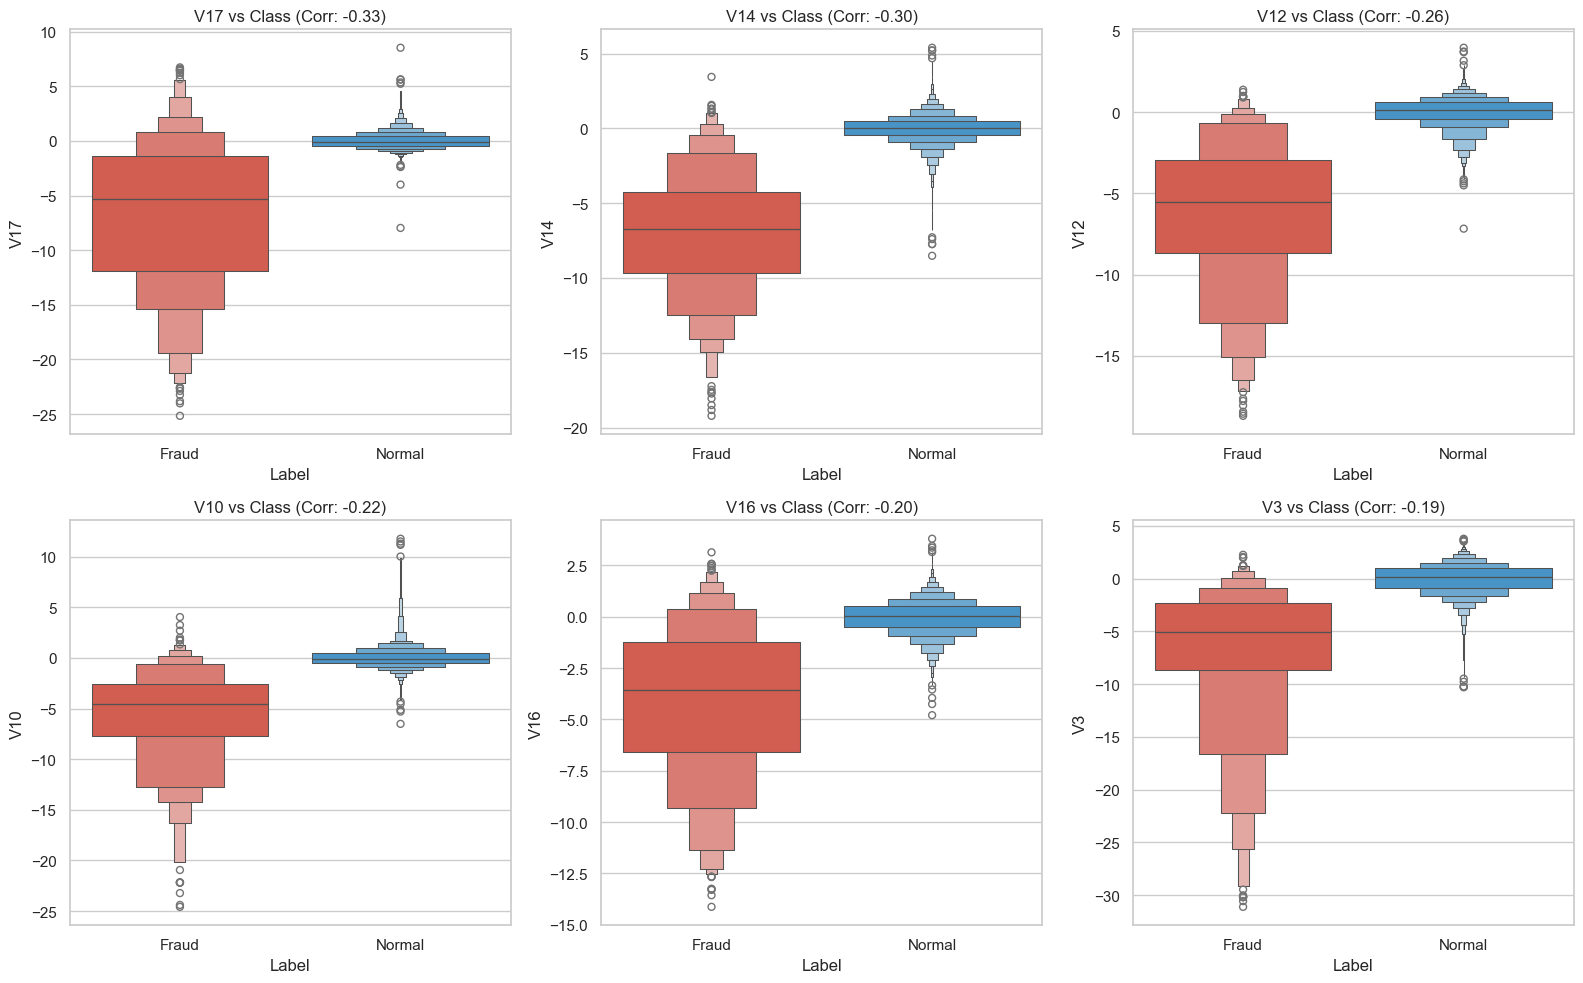

In [21]:
# 1. Find Top Correlations
corr = df.select_dtypes(include=[np.number]).corr()['Class'].drop('Class')
top_features = corr.abs().nlargest(6).index.tolist()

# 2. Stratified Sample for Cleaner Plotting
# Take ALL frauds + Random sample of 10,000 Normals
df_fraud = df[df['Class'] == 1]
df_normal = df[df['Class'] == 0].sample(10000, random_state=42)
df_sample = pd.concat([df_fraud, df_normal])
df_sample['Label'] = df_sample['Class'].map({0: 'Normal', 1: 'Fraud'})

# 3. Plot
plt.figure(figsize=(16, 10))
for i, col in enumerate(top_features):
    plt.subplot(2, 3, i + 1)
    sns.boxenplot(
        data=df_sample, x='Label', y=col, hue='Label',
        palette={"Normal": "#3498db", "Fraud": "#e74c3c"},
        legend=False
    )
    plt.title(f"{col} vs Class (Corr: {corr[col]:.2f})")

plt.tight_layout()
plt.show()

#### What the result suggests:

1. Across all six features, fraud transactions are strongly shifted away from normal transactions, especially toward more negative values.

2. Normal points cluster tightly around a narrow band (often near ~0), while Fraud shows:

* a much lower median,
* a broader spread,
* and heavier tails/outliers.

3. The separation is most striking for V17, V14, V12 (largest magnitude correlations shown), which suggests these are likely among my strongest predictors.

4. Practical implication: these features carry a clear signal for classification. I can see exactly what I'd ideally find in EDA: systematic distribution shift between classes rather than just random noise.